In [14]:

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

from input import input
import config
from model import generics, hybrid_system_exp, grid_search_exp
from metrics import metrics
import numpy as np
from sklearn.linear_model import PoissonRegressor
    
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


consumocoformated.txt
> /home/domingossj/experiments/src/model/hybrid_system_exp.py(538)exec_comb()
    537 
--> 538             x_train, y_train, x_val, y_val, x_test, min_max_scaler_y = self.split_training_test(df_input, df_output, base_info)
    539             (



ipdb>  df_input['ens']= df_input['linear_forecast'] + df_input['nonlinear_forecast']
ipdb>  df_input['output'] = df_output.values
ipdb>  df_input[['output', 'ens', 'linear_forecast']].iloc[-100:].plot()


<Axes: >


ipdb>  exit


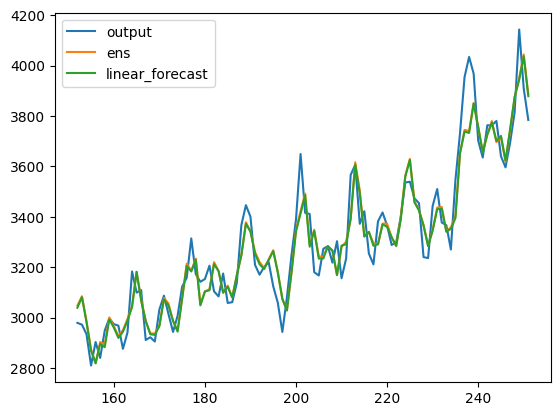

In [17]:
model = PoissonRegressor(max_iter=10000)

experiment_id = 'consumoenergia'
model_name = f'comb'
normalize = True
force = True
model_exec = 1

experiment_params = {
    'nonlinear_model': '1arimamlp',
    "lag_size": None,
    'diff_kpss': False,
    'test_size': config.TEST_SIZE,
    'val_size': 0,
    'horizon': 1
}

for base_name in config.BASE_NAME_LIST:
    print(base_name)
    
    rc = hybrid_system_exp.ResidualCombination(
        model,
        experiment_id, 
        base_name, 
        model_name, 
        force,
        normalize,
        experiment_params 
    )
    rc.exec_comb()
